# 05 - Comprehensive Measurement of Model Performance

This notebook provides a complete guide to evaluating PyTorch ANNs for both **Classification** and **Regression** tasks:

---

## Evaluation Metrics & Diagnostics Covered:

1. **Classification Metrics**:
   - Softmax conversion & Argmax decision boundary.
   - Confusion Matrix (Heatmap).
   - Precision, Recall, F1-Score (Micro, Macro, Weighted).
   - One-vs-Rest (OvR) ROC Curve & AUC Score.
   - Precision-Recall (PR) Curves.
2. **Regression Metrics**:
   - Mean Squared Error (MSE), Root Mean Squared Error (RMSE).
   - Mean Absolute Error (MAE), Coefficient of Determination ($R^2$).
   - Residual Distribution & Scatter Diagnostics.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score
)

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## Part 1: Multiclass Classification Evaluation

We train a 3-class classifier and generate complete model diagnostics.


In [2]:
X_c, y_c = make_classification(
    n_samples=1000, n_features=15, n_informative=10, n_classes=3, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X_c, y_c, test_size=0.25, random_state=42)

scaler_c = StandardScaler()
X_tr_s = scaler_c.fit_transform(X_train)
X_te_s = scaler_c.transform(X_test)

X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_te_t = torch.tensor(X_te_s, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.long)

class ClassifierANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(15, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
    def forward(self, x):
        return self.net(x)

clf = ClassifierANN()
optimizer = torch_optim.Adam(clf.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

# Train Classifier
clf.train()
for epoch in range(40):
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(clf(bx), by)
        loss.backward()
        optimizer.step()

# Extract Probabilities and Class Predictions
clf.eval()
with torch.no_grad():
    raw_logits = clf(X_te_t)
    probabilities = F.softmax(raw_logits, dim=1).numpy()
    predictions = torch.argmax(raw_logits, dim=1).numpy()

y_true = y_test


### 1.1 Confusion Matrix & Classification Report


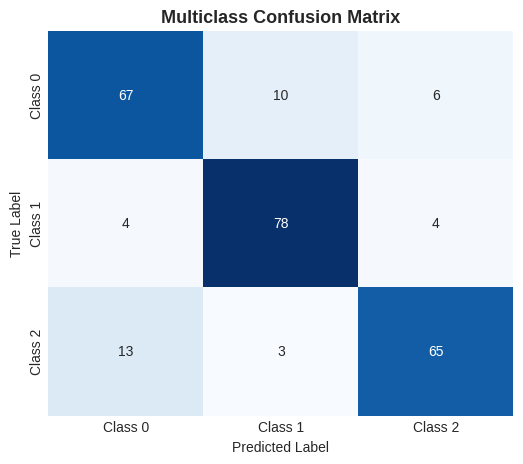

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.80      0.81      0.80        83
     Class 1       0.86      0.91      0.88        86
     Class 2       0.87      0.80      0.83        81

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



In [3]:
cm = confusion_matrix(y_true, predictions)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
ax.set_title('Multiclass Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.show()

print("=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, predictions, target_names=['Class 0', 'Class 1', 'Class 2']))


### 1.2 One-vs-Rest (OvR) ROC & Precision-Recall Curves


/tmp/ipykernel_4955/2433140715.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  axes[0].plot([0, 1], [0, 1], 'k--', linestyle=':')


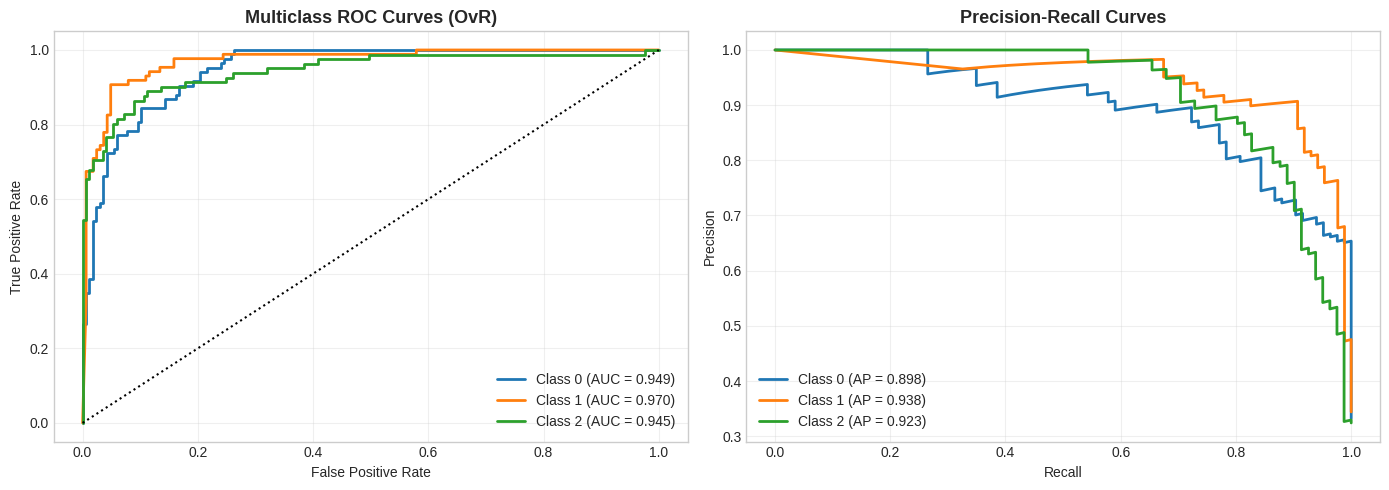

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# One-vs-Rest ROC Curves
for i in range(3):
    y_binary = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linestyle=':')
axes[0].set_title('Multiclass ROC Curves (OvR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for i in range(3):
    y_binary = (y_true == i).astype(int)
    precision, recall, _ = precision_recall_curve(y_binary, probabilities[:, i])
    ap_score = average_precision_score(y_binary, probabilities[:, i])
    axes[1].plot(recall, precision, label=f'Class {i} (AP = {ap_score:.3f})', linewidth=2)

axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 2: Regression Performance & Diagnostics

We construct a non-linear target: $y = 3 x_1^2 + \sin(2 x_2) + \epsilon$ and train a PyTorch ANN Regressor.


In [5]:
# Generate non-linear regression data
X_r, y_r = make_regression(n_samples=800, n_features=10, noise=15.0, random_state=42)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_r, y_r, test_size=0.25, random_state=42)

scaler_r = StandardScaler()
X_tr_rs = scaler_r.fit_transform(X_tr_r)
X_te_rs = scaler_r.transform(X_te_r)

X_tr_rt = torch.tensor(X_tr_rs, dtype=torch.float32)
y_tr_rt = torch.tensor(y_tr_r, dtype=torch.float32).unsqueeze(1)
X_te_rt = torch.tensor(X_te_rs, dtype=torch.float32)
y_te_rt = torch.tensor(y_te_r, dtype=torch.float32).unsqueeze(1)

class RegressorANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Single continuous output
        )
    def forward(self, x):
        return self.net(x)

reg = RegressorANN()
optimizer_r = torch_optim.Adam(reg.parameters(), lr=0.01)
criterion_r = nn.MSELoss()

reg_loader = DataLoader(TensorDataset(X_tr_rt, y_tr_rt), batch_size=32, shuffle=True)

# Train Regressor
reg.train()
for epoch in range(60):
    for bx, by in reg_loader:
        optimizer_r.zero_grad()
        loss = criterion_r(reg(bx), by)
        loss.backward()
        optimizer_r.step()

reg.eval()
with torch.no_grad():
    y_pred_reg = reg(X_te_rt).numpy().flatten()
y_true_reg = y_te_r


### 2.1 Computing Regression Metrics ($MSE, RMSE, MAE, R^2$) & Residual Plots


REGRESSION METRICS SUMMARY
Mean Squared Error (MSE):      320.6377
Root Mean Squared Error (RMSE): 17.9064
Mean Absolute Error (MAE):     14.2404
R-squared Score (R^2):          0.9920


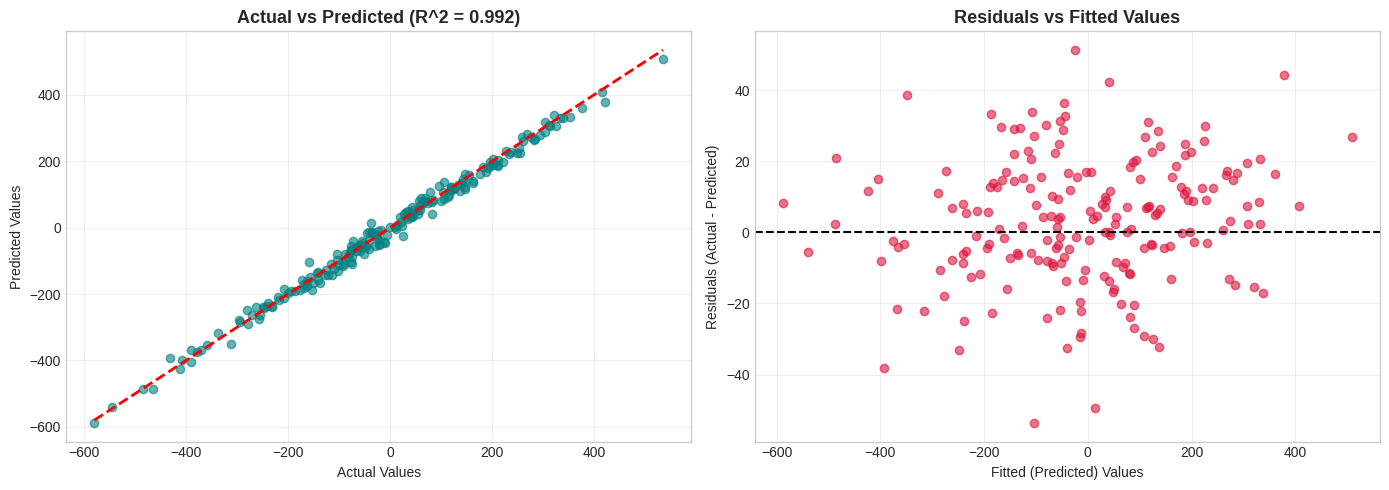

In [6]:
mse = mean_squared_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_reg, y_pred_reg)
r2 = r2_score(y_true_reg, y_pred_reg)

print("=" * 50)
print("REGRESSION METRICS SUMMARY")
print("=" * 50)
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"R-squared Score (R^2):          {r2:.4f}")
print("=" * 50)

residuals = y_true_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted Scatter
axes[0].scatter(y_true_reg, y_pred_reg, alpha=0.6, color='teal')
axes[0].plot([y_true_reg.min(), y_true_reg.max()], [y_true_reg.min(), y_true_reg.max()], 'r--', linewidth=2)
axes[0].set_title(f'Actual vs Predicted (R^2 = {r2:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].grid(True, alpha=0.3)

# Residual Scatter Plot
axes[1].scatter(y_pred_reg, residuals, alpha=0.6, color='crimson')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Fitted Values', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fitted (Predicted) Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
